In [1]:
import numpy as np
import matplotlib.pyplot as plt

# House sizes (sq ft)
X = np.array([800, 1100, 1300, 1500, 1700, 1900, 2100, 2300, 2500, 2800])

# Prices ($k)
y = np.array([150, 195, 210, 260, 295, 320, 355, 370, 410, 460])

In [2]:
def predict(x,w,b):
    return w * x + b


predictions = predict(X, w=0.15, b=50)
print(predictions)
np.mean(predictions)
np.sum(predictions)

[170. 215. 245. 275. 305. 335. 365. 395. 425. 470.]


np.float64(3200.0)

In [ ]:
def mse(y_true,y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true,y_pred):
    return np.abs(y_true - y_pred).mean()

lines = [
    (0.05, 100, "flat line, high base"),
    (0.30, 10,  "steep line, low base"),
    (0.15, 30,  "reasonable guess"),
]
for w, b, label in lines:
    predictions = predict(X, w=w, b=b)
    print(f"{label} - MSE: {mse(y, predictions):.2f}, MAE: {mae(y, predictions):.2f}")



flat line, high base - MSE: 16782.50, MAE: 112.50
steep line, low base - MSE: 69007.50, MAE: 247.50
reasonable guess - MSE: 62.50, MAE: 6.50


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual prices')

x_line = np.linspace(X.min(), X.max(), 100)
for w, b, label in lines:
    plt.plot(x_line, predict(x_line, w, b), label=label)

plt.xlabel("House Size (sq ft)")
plt.ylabel("Price ($k)")
plt.legend()
plt.title("Linear Regression Candidates")
plt.show()


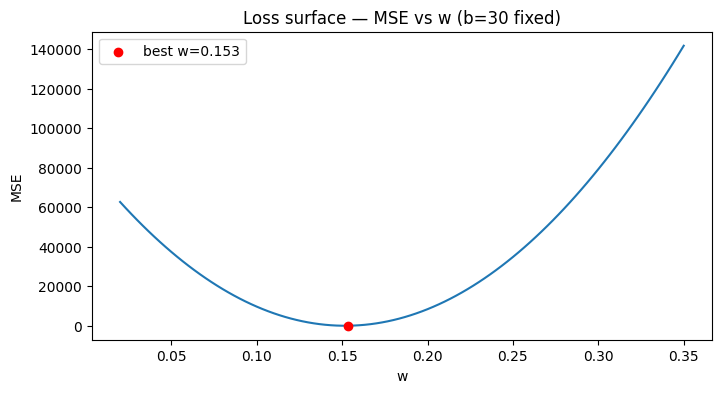

Best w found: 0.1533  →  MSE=59.6


In [8]:
w_values = np.linspace(0.02, 0.35, 100)

# compute mse for each w (b fixed at 30)
mse_values = [mse(y, predict(X, w, 30)) for w in w_values]

# find the best w
best_w = w_values[np.argmin(mse_values)]
best_mse = min(mse_values)

plt.figure(figsize=(8, 4))
# your plot here — line for mse_values, mark best_w with a dot
plt.xlabel('w')
plt.ylabel('MSE')
plt.title('Loss surface — MSE vs w (b=30 fixed)')
plt.plot(w_values, mse_values)
plt.scatter([best_w], [best_mse], color='red', zorder=5, label=f'best w={best_w:.3f}')
plt.legend()
plt.show()

print(f"Best w found: {best_w:.4f}  →  MSE={best_mse:.1f}")
